# Modelos base sobre el índice de aptitud solar

Este cuaderno corre los modelos base del curso sobre la base limpia del EDA (`dataset_eda_corregido.csv`, derivada del dataset de Mantilla-Guerra et al., 2026), en dos tareas:

- Clasificación de `solar_aptittude_class` (Baja, Media, Alta).
- Regresión de `solar_aptitude`, el índice continuo.

Primero se entrenan los modelos con hiperparámetros por defecto en cuatro escenarios (bloques espaciales o partición aleatoria, con o sin latitud y longitud),
para ver cuánto depende el resultado de la ubicación. Después se repiten con ajuste de hiperparámetros por validación anidada en el escenario principal.

## Esquema del benchmark

La partición va primero. Todo lo que se aprende de los datos se ajusta solo con el entrenamiento de cada pliegue.

![Esquema del benchmark mundial](fig_pipeline_benchmark_mundial.png)

## 1. Diseño

Datos: 57,976 plantas y las 15 predictoras del EDA corregido.

Validación externa: `StratifiedGroupKFold` con 5 pliegues, donde cada grupo es un bloque de 5° × 5° (`spatial_block`). Un bloque entero cae en entrenamiento o en prueba,
nunca partido. Con partición aleatoria, plantas vecinas quedan a los dos lados y el resultado sale optimista (Roberts et al., 2017; Ploton et al., 2020).

Fuga de información: la partición se hace primero. La imputación por mediana de `log_dist_to_road` (63 vacíos), el escalado y la calibración de probabilidades van
dentro de un `Pipeline`, así que se ajustan solo con el entrenamiento de cada pliegue. En el ajuste de hiperparámetros, la búsqueda usa solo el entrenamiento
del pliegue externo y lo parte otra vez por bloques; el pliegue externo de prueba no se toca hasta medir.

Métricas de clasificación: la principal es el F1 macro, el promedio del F1 de las tres clases, porque la clase Baja es el 3 % y la exactitud premiaría ignorarla.
También se reportan la exactitud, la exactitud balanceada (promedio del recall por clase), la precisión y el recall macro, y el F1 de la clase Baja.
El AUC ROC macro, uno contra el resto, dice qué tan bien ordenan las probabilidades a cada clase frente a las otras, sin depender de un umbral.
El kappa ponderado cuadrático tiene en cuenta que las clases tienen orden (Baja < Media < Alta): confundir Baja con Alta debe costar más que confundir Media con Alta.

Métricas de regresión: R², RMSE (castiga más los errores grandes) y MAE (error absoluto medio, en las unidades del índice).

Escala: el SVM con kernel RBF crece entre cuadrático y cúbico con el número de filas, así que se entrena con una submuestra de 8,000 filas del entrenamiento de cada pliegue.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import LinearSVC, SVC, SVR, LinearSVR
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, GroupKFold, GridSearchCV, cross_validate
from sklearn.metrics import (make_scorer, f1_score, cohen_kappa_score, accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, roc_auc_score, roc_curve, r2_score, mean_absolute_error, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42

df = pd.read_csv("dataset_eda_corregido.csv")
X15 = ["latitude", "longitude", "elevation", "slope", "curvature", "aspect_sin", "aspect_cos", "is_flat",
       "wind_sin", "wind_cos", "log_dist_to_road", "ambient_temperature", "humidity", "wind_speed", "ghi"]
X13 = [c for c in X15 if c not in ("latitude", "longitude")]
CLASES = ["Baja", "Media", "Alta"]                       # orden natural del índice
y_clf = pd.Categorical(df.solar_aptittude_class, categories=CLASES).codes
y_reg = df.solar_aptitude.values
grupos = df.spatial_block.astype(str).values

print("Filas:", len(df), "| bloques:", df.spatial_block.nunique())
print("Clases:", dict(zip(CLASES, np.bincount(y_clf))))
print("Vacíos por columna:", df[X15].isna().sum()[lambda s: s > 0].to_dict())

Filas: 57976 | bloques: 496
Clases: {'Baja': np.int64(1826), 'Media': np.int64(12756), 'Alta': np.int64(43394)}
Vacíos por columna: {'log_dist_to_road': 63}


In [2]:
class Submuestra(BaseEstimator):
    # Entrena el estimador en una submuestra aleatoria del entrenamiento (SVM con kernel). Expone probabilidades si el estimador las tiene.
    def __init__(self, est=None, n=8000, random_state=SEED):
        self.est, self.n, self.random_state = est, n, random_state
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        i = rng.choice(len(X), min(self.n, len(X)), replace=False)
        self.est_ = clone(self.est).fit(np.asarray(X)[i], np.asarray(y)[i])
        if hasattr(self.est_, "classes_"):
            self.classes_ = self.est_.classes_
        return self
    def predict(self, X): return self.est_.predict(X)
    def predict_proba(self, X): return self.est_.predict_proba(X)

class SubClf(ClassifierMixin, Submuestra): pass
class SubReg(RegressorMixin, Submuestra): pass

def pipe(modelo):
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler()), ("m", modelo)])

CLF = {
    "Referencia: clase mayoritaria": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=1000),
    "Regresión logística balanceada": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Naive Bayes gaussiano": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM lineal (calibrado)": CalibratedClassifierCV(LinearSVC(dual=False), cv=3),
    "SVM RBF (8 mil filas)": SubClf(SVC(kernel="rbf", probability=True, random_state=SEED)),
}
REG = {
    "Referencia: media": DummyRegressor(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "KNN": KNeighborsRegressor(n_neighbors=15),
    "SVR lineal": LinearSVR(dual=False, loss="squared_epsilon_insensitive", random_state=SEED),
    "SVR RBF (8 mil filas)": SubReg(SVR(kernel="rbf")),
}

kappa_c = make_scorer(cohen_kappa_score, weights="quadratic")
f1_baja = make_scorer(f1_score, labels=[0], average="macro")
SC_CLF = {"f1_macro": "f1_macro", "exactitud": "accuracy", "exactitud_bal": "balanced_accuracy", "precision_macro": "precision_macro",
          "recall_macro": "recall_macro", "f1_baja": f1_baja, "auc_ovr": "roc_auc_ovr", "kappa_cuad": kappa_c}
SC_REG = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

def particiones(tipo):
    if tipo == "bloques 5°":
        return list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(df, y_clf, grupos))
    return list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(df, y_clf))

## 2. Modelos con hiperparámetros por defecto, cuatro escenarios

Cada celda es el promedio de los 5 pliegues externos. `_de` es la desviación estándar entre pliegues.

In [3]:
def corre(tarea):
    modelos, y, sc = (CLF, y_clf, SC_CLF) if tarea == "clf" else (REG, y_reg, SC_REG)
    filas = []
    for vars_nombre, cols in [("con lat/lon", X15), ("sin lat/lon", X13)]:
        for tipo in ["bloques 5°", "aleatoria"]:
            cv = particiones(tipo)
            for nombre, modelo in modelos.items():
                t0 = time.time()
                r = cross_validate(pipe(modelo), df[cols].values, y, cv=cv, scoring=sc, n_jobs=-1, error_score=np.nan)
                fila = {"modelo": nombre, "variables": vars_nombre, "validación": tipo, "segundos": time.time() - t0}
                for k in sc:
                    v = r[f"test_{k}"]
                    v = -v if k in ("rmse", "mae") else v
                    fila[k], fila[k + "_de"] = np.nanmean(v), np.nanstd(v)
                filas.append(fila)
    return pd.DataFrame(filas)

res_clf = corre("clf")
res_clf.to_csv("resultados_benchmark_clasificacion.csv", index=False)
res_clf.pivot_table(index="modelo", columns=["variables", "validación"], values="f1_macro").reindex(list(CLF)).round(3)

variables                      con lat/lon            sin lat/lon           
validación                       aleatoria bloques 5°   aleatoria bloques 5°
modelo                                                                      
Referencia: clase mayoritaria        0.285      0.285       0.285      0.285
Regresión logística                  0.613      0.599       0.381      0.377
Regresión logística balanceada       0.632      0.629       0.488      0.470
Naive Bayes gaussiano                0.458      0.448       0.148      0.146
KNN                                  0.807      0.787       0.730      0.658
SVM lineal (calibrado)               0.533      0.516       0.310      0.312
SVM RBF (8 mil filas)                0.826      0.812       0.680      0.617

In [4]:
principal = res_clf[(res_clf.validación == "bloques 5°") & (res_clf.variables == "con lat/lon")].set_index("modelo").reindex(list(CLF))
principal[list(SC_CLF)].round(3)

,f1_macro,exactitud,exactitud_bal,precision_macro,recall_macro,f1_baja,auc_ovr,kappa_cuad
modelo,,,,,,,,
Referencia: clase mayoritaria,0.285,0.748,0.333,0.249,0.333,0.000,0.500,0.000
Regresión logística,0.599,0.768,0.559,0.695,0.559,0.523,0.865,0.367
Regresión logística balanceada,0.629,0.719,0.798,0.587,0.798,0.507,0.873,0.481
Naive Bayes gaussiano,0.448,0.574,0.657,0.515,0.657,0.169,0.768,0.261
KNN,0.787,0.897,0.742,0.859,0.742,0.658,0.951,0.737
SVM lineal (calibrado),0.516,0.753,0.479,0.668,0.479,0.358,0.874,0.246
SVM RBF (8 mil filas),0.812,0.896,0.772,0.869,0.772,0.747,0.958,0.751


In [5]:
res_reg = corre("reg")
res_reg.to_csv("resultados_benchmark_regresion.csv", index=False)
display(res_reg.pivot_table(index="modelo", columns=["variables", "validación"], values="r2").reindex(list(REG)).round(3))
res_reg[(res_reg.validación == "bloques 5°") & (res_reg.variables == "con lat/lon")].set_index("modelo").reindex(list(REG))[["r2", "r2_de", "rmse", "mae", "segundos"]].round(4)

variables             con lat/lon            sin lat/lon           
validación              aleatoria bloques 5°   aleatoria bloques 5°
modelo                                                             
Referencia: media          -0.000     -0.002      -0.000     -0.002
Ridge                       0.490      0.479       0.220      0.195
Lasso                       0.488      0.478       0.219      0.195
KNN                         0.818      0.790       0.656      0.480
SVR lineal                  0.490      0.479       0.220      0.195
SVR RBF (8 mil filas)       0.762      0.734       0.560      0.427

,r2,r2_de,rmse,mae,segundos
modelo,,,,,
Referencia: media,-0.0015,0.0018,0.1335,0.1033,0.4880
Ridge,0.4790,0.0396,0.0962,0.0694,0.8151
Lasso,0.4780,0.0361,0.0963,0.0694,0.6825
KNN,0.7904,0.0209,0.0609,0.0369,17.4884
SVR lineal,0.4790,0.0396,0.0962,0.0694,0.3163
SVR RBF (8 mil filas),0.7335,0.0234,0.0687,0.0527,1.4277


## 3. Leave-one-region-out

Se entrena con dos macrorregiones y se predice la tercera (leave-one-region-out: una región completa queda fuera). Es la prueba más dura: mide si el modelo sirve en un continente que no vio. Se reporta el R² de regresión.

In [6]:
region = df.macro_region.values
filas = []
for vars_nombre, cols in [("con lat/lon", X15), ("sin lat/lon", X13)]:
    for nombre, modelo in REG.items():
        for r in np.unique(region):
            te = region == r
            m = pipe(clone(modelo)).fit(df.loc[~te, cols].values, y_reg[~te])
            filas.append({"modelo": nombre, "variables": vars_nombre, "región fuera": r,
                          "r2": r2_score(y_reg[te], m.predict(df.loc[te, cols].values))})
lro = pd.DataFrame(filas)
lro.to_csv("resultados_benchmark_region_fuera.csv", index=False)
lro.pivot_table(index="modelo", columns=["variables", "región fuera"], values="r2").reindex(list(REG)).round(2)

variables             con lat/lon                                       \
región fuera             Américas Asia/Oceanía Europa/África/M.Oriente   
modelo                                                                   
Referencia: media           -1.03        -3.59                   -0.71   
Ridge                       -5.41        -4.15                   -0.11   
Lasso                       -4.60        -4.16                   -0.11   
KNN                         -1.49        -5.94                   -1.18   
SVR lineal                  -5.40        -4.15                   -0.11   
SVR RBF (8 mil filas)       -0.85        -8.38                   -0.19   

variables             sin lat/lon                                       
región fuera             Américas Asia/Oceanía Europa/África/M.Oriente  
modelo                                                                  
Referencia: media           -1.03        -3.59                   -0.71  
Ridge                       -3.18        -6.40                   -0.50  
Lasso                       -3.05        -6.14                   -0.50  
KNN                         -3.22        -7.18                   -1.04  
SVR lineal                  -3.18        -6.40                   -0.50  
SVR RBF (8 mil filas)       -2.64        -7.84                   -1.27

Un R² negativo significa que el modelo predice peor que el promedio de la región de prueba. Hasta la referencia sale negativa, porque el promedio
del índice cambia de una región a otra.

## 4. Ajuste de hiperparámetros con validación anidada

Escenario principal: bloques de 5° y con latitud y longitud.

- Bucle externo: los mismos 5 pliegues por bloques. Solo mide.
- Bucle interno: dentro del entrenamiento de cada pliegue externo, `GridSearchCV` con 3 pliegues que también agrupan por bloque. Elige los hiperparámetros
  con F1 macro (clasificación) o R² (regresión) y reentrena con todo el entrenamiento externo.
- El `Pipeline` completo (imputar, escalar, calibrar, modelo) se ajusta dentro de cada pliegue interno, así que la búsqueda tampoco ve datos de validación.

Las grillas usan escala logarítmica para los parámetros de regularización (C, alpha), como indica la guía de la Entrega 3. Son pequeñas a propósito: este es el benchmark base y no
busca sacarle todo a cada modelo. Se reporta el resultado externo y los hiperparámetros elegidos en cada pliegue, para ver si son estables.

In [7]:
GRID_CLF = {
    "Regresión logística": {"m__C": [0.01, 0.1, 1, 10, 100]},
    "Regresión logística balanceada": {"m__C": [0.01, 0.1, 1, 10, 100]},
    "Naive Bayes gaussiano": {"m__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]},
    "KNN": {"m__n_neighbors": [5, 15, 31, 51], "m__weights": ["uniform", "distance"]},
    "SVM lineal (calibrado)": {"m__estimator__C": [0.01, 0.1, 1, 10]},
    "SVM RBF (8 mil filas)": {"m__est__C": [1, 10], "m__est__gamma": ["scale", 0.3]},
}
GRID_REG = {
    "Ridge": {"m__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    "Lasso": {"m__alpha": [1e-5, 1e-4, 1e-3, 1e-2]},
    "KNN": {"m__n_neighbors": [5, 15, 31, 51], "m__weights": ["uniform", "distance"]},
    "SVR lineal": {"m__C": [0.01, 0.1, 1, 10]},
    "SVR RBF (8 mil filas)": {"m__est__C": [1, 10], "m__est__epsilon": [0.01, 0.05]},
}

def metricas_clf(y, pred, proba):
    return {"f1_macro": f1_score(y, pred, average="macro"), "exactitud": accuracy_score(y, pred),
            "exactitud_bal": balanced_accuracy_score(y, pred), "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y, pred, average="macro"), "f1_baja": f1_score(y, pred, labels=[0], average="macro"),
            "auc_ovr": roc_auc_score(y, proba, multi_class="ovr", average="macro", labels=[0, 1, 2]),
            "kappa_cuad": cohen_kappa_score(y, pred, weights="quadratic")}

def metricas_reg(y, pred):
    return {"r2": r2_score(y, pred), "rmse": np.sqrt(mean_squared_error(y, pred)), "mae": mean_absolute_error(y, pred)}

def anidada(tarea, cols=X15):
    modelos, grids, y = (CLF, GRID_CLF, y_clf) if tarea == "clf" else (REG, GRID_REG, y_reg)
    X = df[cols].values
    externo = particiones("bloques 5°")
    filas, params, probas = [], [], {}
    for nombre, grid in grids.items():
        t0 = time.time()
        oof = np.zeros((len(df), 3)) if tarea == "clf" else None
        for k, (tr, te) in enumerate(externo):
            interno = StratifiedGroupKFold(3, shuffle=True, random_state=SEED) if tarea == "clf" else GroupKFold(3)
            busq = GridSearchCV(pipe(clone(modelos[nombre])), grid, cv=interno,
                                scoring="f1_macro" if tarea == "clf" else "r2", n_jobs=-1, refit=True)
            busq.fit(X[tr], y[tr], groups=grupos[tr])
            if tarea == "clf":
                proba = busq.predict_proba(X[te]); oof[te] = proba
                m = metricas_clf(y[te], busq.predict(X[te]), proba)
            else:
                m = metricas_reg(y[te], busq.predict(X[te]))
            filas.append({"modelo": nombre, "pliegue": k, **m})
            params.append({"modelo": nombre, "pliegue": k, **{p.replace("m__", ""): v for p, v in busq.best_params_.items()}})
        if tarea == "clf":
            probas[nombre] = oof
        print(f"{nombre}: {time.time() - t0:.0f} s")
    return pd.DataFrame(filas), pd.DataFrame(params), probas

anid_clf, par_clf, probas_clf = anidada("clf")
anid_clf.to_csv("resultados_anidada_clasificacion.csv", index=False)
tab_anid_clf = anid_clf.groupby("modelo").mean(numeric_only=True).drop(columns="pliegue").reindex(list(GRID_CLF))
tab_anid_clf.round(3)

Regresión logística: 6 s


Regresión logística balanceada: 4 s


Naive Bayes gaussiano: 2 s


KNN: 195 s


SVM lineal (calibrado): 10 s


SVM RBF (8 mil filas): 100 s


,f1_macro,exactitud,exactitud_bal,precision_macro,recall_macro,f1_baja,auc_ovr,kappa_cuad
modelo,,,,,,,,
Regresión logística,0.600,0.768,0.560,0.694,0.560,0.525,0.865,0.368
Regresión logística balanceada,0.629,0.719,0.798,0.587,0.798,0.506,0.873,0.482
Naive Bayes gaussiano,0.472,0.612,0.674,0.505,0.674,0.208,0.835,0.289
KNN,0.797,0.895,0.767,0.837,0.767,0.694,0.925,0.753
SVM lineal (calibrado),0.516,0.753,0.479,0.668,0.479,0.358,0.874,0.246
SVM RBF (8 mil filas),0.818,0.900,0.793,0.850,0.793,0.744,0.960,0.775


In [8]:
par_clf.set_index(["modelo", "pliegue"])

C  var_smoothing  n_neighbors  \
modelo                         pliegue                                      
Regresión logística            0         10.0            NaN          NaN   
                               1        100.0            NaN          NaN   
                               2         10.0            NaN          NaN   
                               3        100.0            NaN          NaN   
                               4         10.0            NaN          NaN   
Regresión logística balanceada 0          1.0            NaN          NaN   
                               1          1.0            NaN          NaN   
                               2        100.0            NaN          NaN   
                               3        100.0            NaN          NaN   
                               4          1.0            NaN          NaN   
Naive Bayes gaussiano          0          NaN          0.001          NaN   
                               1          NaN          0.001          NaN   
                               2          NaN          0.001          NaN   
                               3          NaN          0.001          NaN   
                               4          NaN          0.001          NaN   
KNN                            0          NaN            NaN          5.0   
                               1          NaN            NaN          5.0   
                               2          NaN            NaN          5.0   
                               3          NaN            NaN          5.0   
                               4          NaN            NaN          5.0   
SVM lineal (calibrado)         0          NaN            NaN          NaN   
                               1          NaN            NaN          NaN   
                               2          NaN            NaN          NaN   
                               3          NaN            NaN          NaN   
                               4          NaN            NaN          NaN   
SVM RBF (8 mil filas)          0          NaN            NaN          NaN   
                               1          NaN            NaN          NaN   
                               2          NaN            NaN          NaN   
                               3          NaN            NaN          NaN   
                               4          NaN            NaN          NaN   

                                         weights  estimator__C  est__C  \
modelo                         pliegue                                   
Regresión logística            0             NaN           NaN     NaN   
                               1             NaN           NaN     NaN   
                               2             NaN           NaN     NaN   
                               3             NaN           NaN     NaN   
                               4             NaN           NaN     NaN   
Regresión logística balanceada 0             NaN           NaN     NaN   
                               1             NaN           NaN     NaN   
                               2             NaN           NaN     NaN   
                               3             NaN           NaN     NaN   
                               4             NaN           NaN     NaN   
Naive Bayes gaussiano          0             NaN           NaN     NaN   
                               1             NaN           NaN     NaN   
                               2             NaN           NaN     NaN   
                               3             NaN           NaN     NaN   
                               4             NaN           NaN     NaN   
KNN                            0         uniform           NaN     NaN   
                               1         uniform           NaN     NaN   
                               2         uniform           NaN     NaN   
                               3         uniform           NaN     NaN   
                         

In [9]:
comp_clf = pd.DataFrame({"F1 macro por defecto": principal.f1_macro, "F1 macro ajustado": tab_anid_clf.f1_macro,
                         "AUC por defecto": principal.auc_ovr, "AUC ajustado": tab_anid_clf.auc_ovr}).reindex(list(GRID_CLF))
comp_clf.round(3)

,F1 macro por defecto,F1 macro ajustado,AUC por defecto,AUC ajustado
modelo,,,,
Regresión logística,0.599,0.600,0.865,0.865
Regresión logística balanceada,0.629,0.629,0.873,0.873
Naive Bayes gaussiano,0.448,0.472,0.768,0.835
KNN,0.787,0.797,0.951,0.925
SVM lineal (calibrado),0.516,0.516,0.874,0.874
SVM RBF (8 mil filas),0.812,0.818,0.958,0.960


In [10]:
anid_reg, par_reg, _ = anidada("reg")
anid_reg.to_csv("resultados_anidada_regresion.csv", index=False)
tab_anid_reg = anid_reg.groupby("modelo").mean(numeric_only=True).drop(columns="pliegue").reindex(list(GRID_REG))
base_reg = res_reg[(res_reg.validación == "bloques 5°") & (res_reg.variables == "con lat/lon")].set_index("modelo")
display(tab_anid_reg.round(4))
display(par_reg.set_index(["modelo", "pliegue"]))
pd.DataFrame({"R² por defecto": base_reg.r2, "R² ajustado": tab_anid_reg.r2}).reindex(list(GRID_REG)).round(3)

Ridge: 2 s


Lasso: 2 s


KNN: 190 s


SVR lineal: 2 s


SVR RBF (8 mil filas): 162 s


,r2,rmse,mae
modelo,,,
Ridge,0.4791,0.0962,0.0695
Lasso,0.4788,0.0962,0.0694
KNN,0.7959,0.0601,0.0363
SVR lineal,0.4790,0.0962,0.0694
SVR RBF (8 mil filas),0.8064,0.0586,0.0365


alpha  n_neighbors   weights      C  \
modelo                pliegue                                             
Ridge                 0        1000.00000          NaN       NaN    NaN   
                      1         100.00000          NaN       NaN    NaN   
                      2        1000.00000          NaN       NaN    NaN   
                      3        1000.00000          NaN       NaN    NaN   
                      4        1000.00000          NaN       NaN    NaN   
Lasso                 0           0.00010          NaN       NaN    NaN   
                      1           0.00001          NaN       NaN    NaN   
                      2           0.00010          NaN       NaN    NaN   
                      3           0.00010          NaN       NaN    NaN   
                      4           0.00100          NaN       NaN    NaN   
KNN                   0               NaN          5.0  distance    NaN   
                      1               NaN          5.0  distance    NaN   
                      2               NaN          5.0  distance    NaN   
                      3               NaN          5.0  distance    NaN   
                      4               NaN         15.0  distance    NaN   
SVR lineal            0               NaN          NaN       NaN   0.01   
                      1               NaN          NaN       NaN   0.10   
                      2               NaN          NaN       NaN   0.10   
                      3               NaN          NaN       NaN  10.00   
                      4               NaN          NaN       NaN   0.01   
SVR RBF (8 mil filas) 0               NaN          NaN       NaN    NaN   
                      1               NaN          NaN       NaN    NaN   
                      2               NaN          NaN       NaN    NaN   
                      3               NaN          NaN       NaN    NaN   
                      4               NaN          NaN       NaN    NaN   

                               est__C  est__epsilon  
modelo                pliegue                        
Ridge                 0           NaN           NaN  
                      1           NaN           NaN  
                      2           NaN           NaN  
                      3           NaN           NaN  
                      4           NaN           NaN  
Lasso                 0           NaN           NaN  
                      1           NaN           NaN  
                      2           NaN           NaN  
                      3           NaN           NaN  
                      4           NaN           NaN  
KNN                   0           NaN           NaN  
                      1           NaN           NaN  
                      2           NaN           NaN  
                      3           NaN           NaN  
                      4           NaN           NaN  
SVR lineal            0           NaN           NaN  
                      1           NaN           NaN  
                      2           NaN           NaN  
                      3           NaN           NaN  
                      4           NaN           NaN  
SVR RBF (8 mil filas) 0           1.0          0.01  
                      1           1.0          0.01  
                      2           1.0          0.01  
                      3           1.0          0.01  
                      4           1.0          0.01

,R² por defecto,R² ajustado
modelo,,
Ridge,0.479,0.479
Lasso,0.478,0.479
KNN,0.790,0.796
SVR lineal,0.479,0.479
SVR RBF (8 mil filas),0.734,0.806


## 5. Gráficas

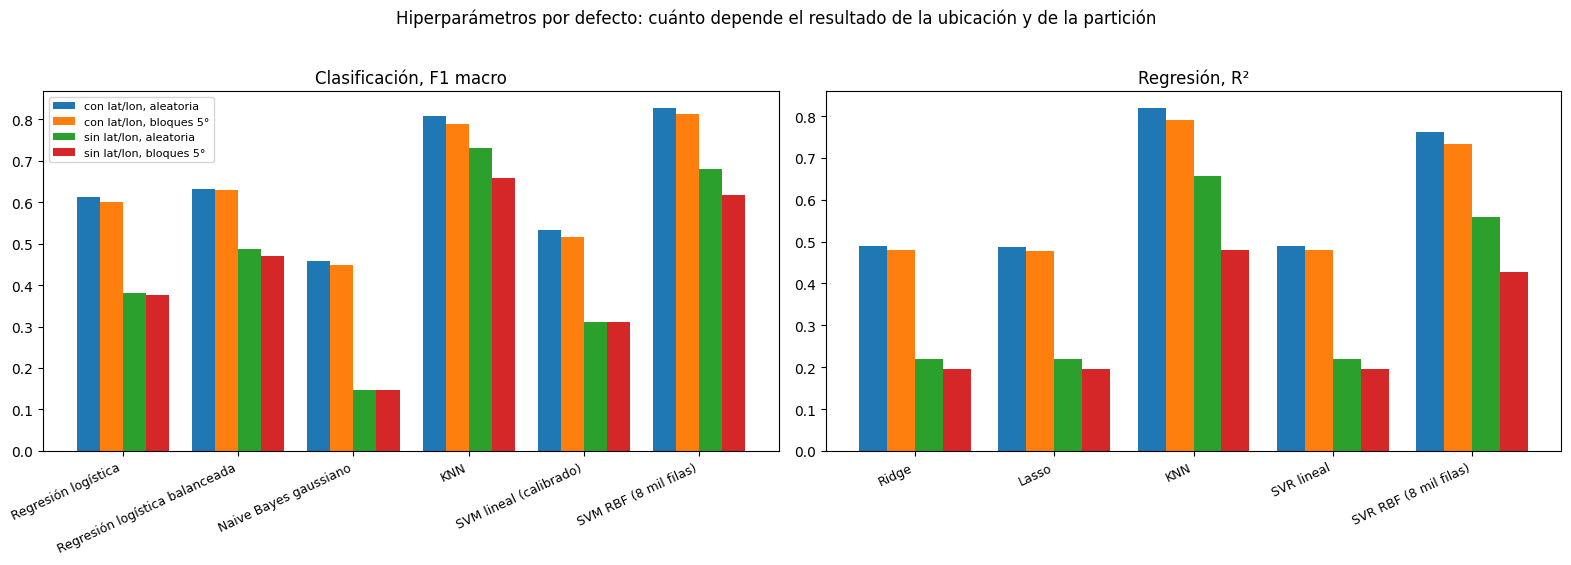

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, (res, met, orden, titulo) in zip(axes, [(res_clf, "f1_macro", list(CLF), "Clasificación, F1 macro"), (res_reg, "r2", list(REG), "Regresión, R²")]):
    t = res.pivot_table(index="modelo", columns=["variables", "validación"], values=met).reindex(orden)
    t = t.drop(index=[i for i in t.index if i.startswith("Referencia")])
    xs = np.arange(len(t.index)); w = 0.2
    for k, col in enumerate([("con lat/lon", "aleatoria"), ("con lat/lon", "bloques 5°"), ("sin lat/lon", "aleatoria"), ("sin lat/lon", "bloques 5°")]):
        ax.bar(xs + (k - 1.5) * w, t[col], w, label=f"{col[0]}, {col[1]}")
    ax.set_xticks(xs); ax.set_xticklabels(t.index, rotation=25, ha="right", fontsize=9)
    ax.set_title(titulo); ax.axhline(0, color="k", lw=.6)
axes[0].legend(fontsize=8)
fig.suptitle("Hiperparámetros por defecto: cuánto depende el resultado de la ubicación y de la partición", y=1.02)
fig.tight_layout(); fig.savefig("fig_benchmark_modelos.png", dpi=130, bbox_inches="tight"); plt.show()

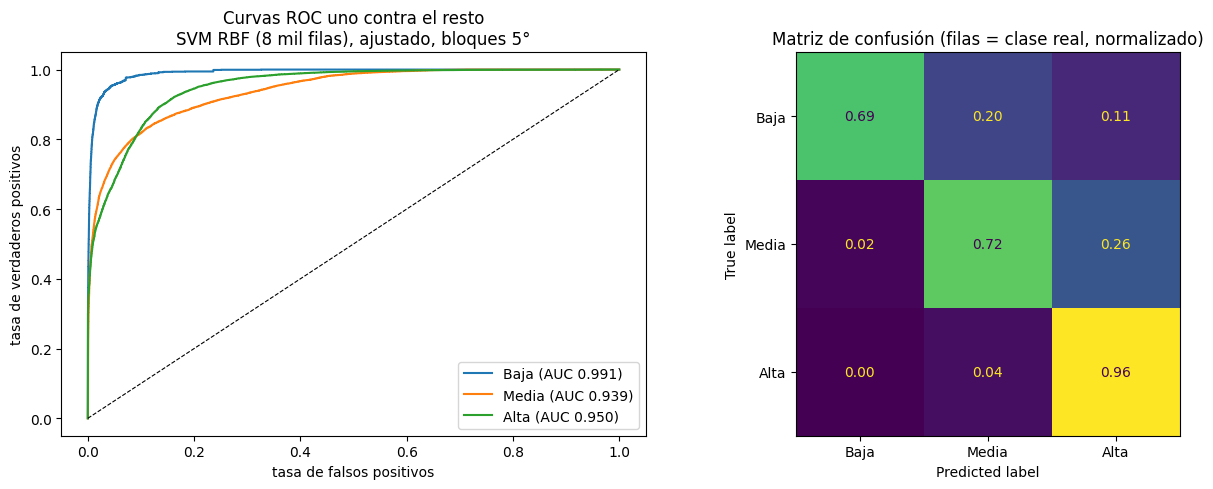

In [12]:
mejor = tab_anid_clf.f1_macro.idxmax()
proba = probas_clf[mejor]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
Y = label_binarize(y_clf, classes=[0, 1, 2])
for c, nombre in enumerate(CLASES):
    fpr, tpr, _ = roc_curve(Y[:, c], proba[:, c])
    axes[0].plot(fpr, tpr, label=f"{nombre} (AUC {roc_auc_score(Y[:, c], proba[:, c]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=.8); axes[0].set_xlabel("tasa de falsos positivos"); axes[0].set_ylabel("tasa de verdaderos positivos")
axes[0].set_title(f"Curvas ROC uno contra el resto\n{mejor}, ajustado, bloques 5°"); axes[0].legend()
ConfusionMatrixDisplay(confusion_matrix(y_clf, proba.argmax(1), normalize="true"), display_labels=CLASES).plot(ax=axes[1], values_format=".2f", colorbar=False)
axes[1].set_title("Matriz de confusión (filas = clase real, normalizado)")
fig.tight_layout(); fig.savefig("fig_benchmark_roc_confusion.png", dpi=130, bbox_inches="tight"); plt.show()

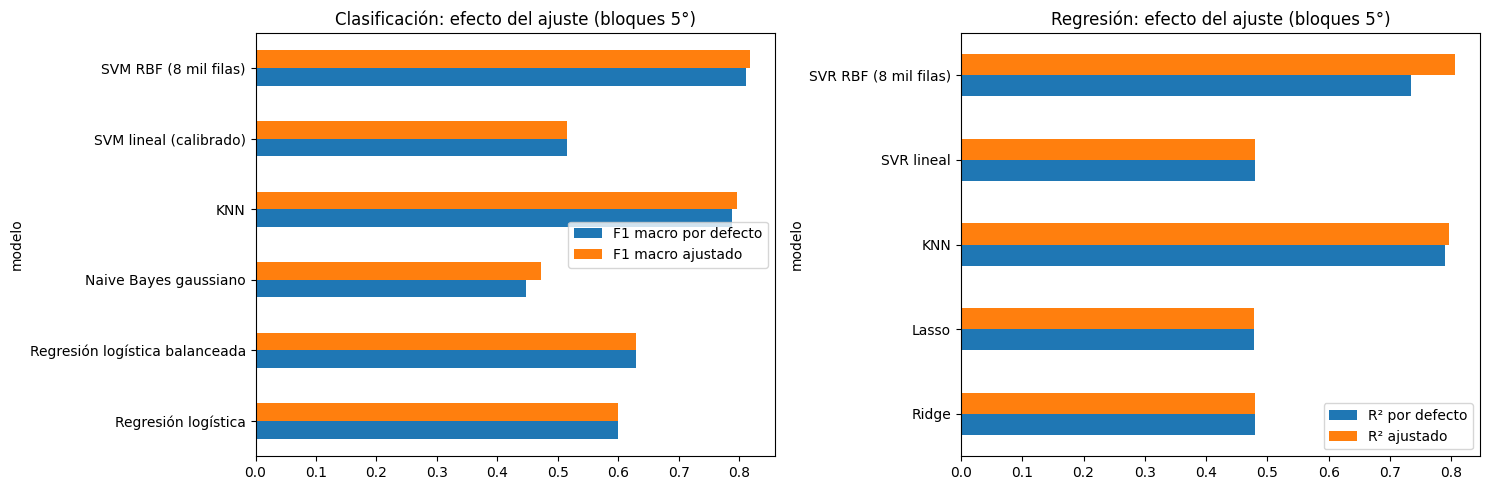

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comp_clf[["F1 macro por defecto", "F1 macro ajustado"]].plot.barh(ax=axes[0]); axes[0].set_title("Clasificación: efecto del ajuste (bloques 5°)")
pd.DataFrame({"R² por defecto": base_reg.r2, "R² ajustado": tab_anid_reg.r2}).reindex(list(GRID_REG)).plot.barh(ax=axes[1])
axes[1].set_title("Regresión: efecto del ajuste (bloques 5°)")
fig.tight_layout(); fig.savefig("fig_benchmark_ajuste.png", dpi=130, bbox_inches="tight"); plt.show()

## 6. Cómo leer los resultados

Quitar latitud y longitud, pasar de partición aleatoria a bloques y dejar una región fuera sirven para ver cuánto del resultado viene de la ubicación. Un modelo que cae mucho al quitar latitud y longitud estaba aprendiendo la ubicación y no el terreno, y uno que cae al pasar de partición aleatoria a bloques se apoyaba en plantas vecinas. Si con una región fuera el R² sale negativo, el modelo no sirve fuera de los continentes que vio.

## 7. Conclusiones

Con hiperparámetros ajustados por validación anidada, en bloques de 5° y con latitud y longitud:

- Clasificación: el SVM RBF es el mejor (F1 macro 0.818, AUC 0.960, kappa ponderado 0.775), seguido de KNN (F1 0.797, AUC 0.925). La regresión logística balanceada
  tiene la mejor exactitud balanceada (0.798) pero un F1 macro de 0.629. El SVM lineal (0.516) y Naive Bayes (0.472) quedan abajo. La referencia da 0.285.
- Regresión: el SVR RBF (R² 0.806) y KNN (0.796) superan con claridad a Ridge, Lasso y el SVR lineal (0.479). La referencia da -0.002.

Los contrastes con hiperparámetros por defecto muestran cuánto dependen estos resultados de la ubicación. Sin latitud y longitud, el R² de KNN baja de 0.79 a 0.48.
Con partición aleatoria los resultados salen más altos que con bloques. Dejando una región completa fuera, todos los modelos dan R² negativo, incluida la referencia.

Los modelos lineales quedan bajos, y una explicación probable es que el índice tiene un nivel distinto en cada región y un solo plano no puede representarlo, la no estacionariedad espacial
que describen Brunsdon et al. (1996). KNN y los SVM con kernel ajustan vecindarios locales y aprenden ese nivel.

El ajuste ayudó sobre todo al SVR RBF, de 0.734 a 0.806, porque el margen `epsilon` por defecto de 0.1 era grande para un índice que va de 0 a 0.94. A los modelos lineales casi no les cambió nada.

Límites: grillas pequeñas y SVM con kernel entrenados con 8,000 filas. Los árboles y el balanceo con SMOTE o ADASYN se tratan en los experimentos 2 y 3.

## Referencias

- Brunsdon, C., Fotheringham, A. S. y Charlton, M. E. (1996). Geographically weighted regression: a method for exploring spatial nonstationarity. *Geographical Analysis, 28*(4), 281-298. https://doi.org/10.1111/j.1538-4632.1996.tb00936.x
- Mantilla-Guerra, A., Mejia-Escobar, C., Azorin-Lopez, J. y Garcia-Rodriguez, J. (2026). Global dataset of solar power plants: multidimensional integration and analysis. *Eng, 7*(7), 343. https://doi.org/10.3390/eng7070343
- Ploton, P. et al. (2020). Spatial validation reveals poor predictive performance of large-scale ecological mapping models. *Nature Communications, 11*, 4540. https://doi.org/10.1038/s41467-020-18321-y
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography, 40*(8), 913-929. https://doi.org/10.1111/ecog.02881